In [1]:
import os

os.environ["JAX_ENABLE_X64"] = "1"
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.4' 

%matplotlib widget

import jax
import matplotlib.pyplot as plt
import numpy as np

from temgym_core.components import Detector
from temgym_core.gaussian import (
    run_to_end, 
    circular_input_wave, 
    KrivanekLens, 
    DistortedLens, 
    Biprism,
) 
from temgym_core.evaluate import evaluate_gaussians_gpu_kernel_wrapper
from temgym_core.transfer_matrices import calculate_z1_and_z2_from_M_and_f
from temgym_core.utils import energy2wavelength
from temgym_core.aberrations import KrivanekCoeffs

run_to_end_jit = jax.jit(run_to_end)
run_to_end_vmapped = jax.jit(
    jax.vmap(run_to_end_jit, in_axes=(0, None)), static_argnums=(1,)
)

In [2]:
from temgym_core.gaussian import Lens


def run_model(input_window_width_m=1e-6,
              num_pixels=512,
              voltage_eV=200e3,
              obj_focal_length=2.5e-3,  # 2.5 mm
              obj_magnification=-80,
              projector_focal_length=5e-2,  # 5 mm
              projector_magnification=-50,
              defocus=0.0,
              biprism_deflection=0.0005,
              C12_aberration=0.0,
              C21_aberration=0.0,
              isotropic_distortion=0.0,
              anisotropic_distortion=0.0,
              num_rays=200_000,
              beam_waist=5e-9):

    # View Input Field
    wavelength = energy2wavelength(voltage_eV)
    k = 2 * np.pi / wavelength
    pixel_size = input_window_width_m / num_pixels
    total_mag = obj_magnification * projector_magnification

    input_grid = Detector(
    z=defocus,
    pixel_size=(pixel_size, pixel_size),
    shape=(num_pixels, num_pixels),
    )

    rays_in = circular_input_wave(voltage=voltage_eV,
                                  aperture_radius=input_window_width_m / 4,
                                  num_rays=num_rays,
                                  waist=beam_waist,
                                  z0=defocus)
    
    input_field = evaluate_gaussians_gpu_kernel_wrapper(rays_in, input_grid).block_until_ready()

    plt.figure()
    plt.imshow(np.abs(input_field), extent=input_grid.extent, origin='lower', cmap='inferno')
    plt.title('Input Field Amplitude')

    # Set up Optical System - z1 = object plane distance from objective lens to sample - it's negative since the sample is before the lens
    # z2 = distance from objective lens to it's image plane
    z1, z2 = calculate_z1_and_z2_from_M_and_f(
        M=obj_magnification,
        f=obj_focal_length,
    )
    # z3 = object plane distance from projector lens to it's image plane - again it's negative since the image plane is before the lens
    # z4 = distance fromt projector lens to detector
    z3, z4 = calculate_z1_and_z2_from_M_and_f(
        M=projector_magnification,
        f=projector_focal_length,
    )
    z1, z2, z3, z4 = map(abs, (z1, z2, z3, z4))  # Ensure distances are positive

    aberration_coefficients = KrivanekCoeffs(
        C12=C12_aberration,
        C21=C21_aberration,
    )
    objective_lens = KrivanekLens(z=z1, focal_length=obj_focal_length, coeffs=aberration_coefficients)
    biprism = Biprism(z=z1 + (z2 / 2), strength=biprism_deflection, width=1e-11)
    projector_lens = DistortedLens(z=z1+z2+z3, object_plane_dist=z3, focal_length=projector_focal_length,
                                   IsoDist=isotropic_distortion, AnisoDist=anisotropic_distortion)
    detector = Detector(
        z=z1 + z2, 
        pixel_size=(pixel_size, pixel_size),
        shape=(num_pixels, num_pixels),
    )
    extent = detector.extent

    rays_out = run_to_end_vmapped(rays_in, (objective_lens, detector))
    output_field = evaluate_gaussians_gpu_kernel_wrapper(rays_out, detector).block_until_ready()

    fig, axs = plt.subplots()
    axs.imshow(np.abs(output_field), extent=extent, origin='lower', cmap='inferno')

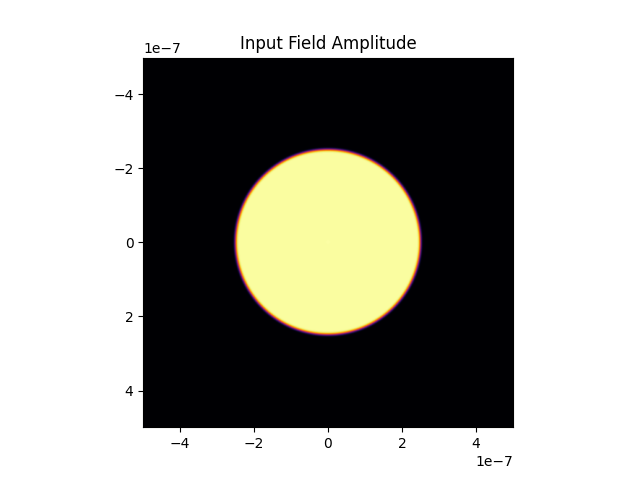

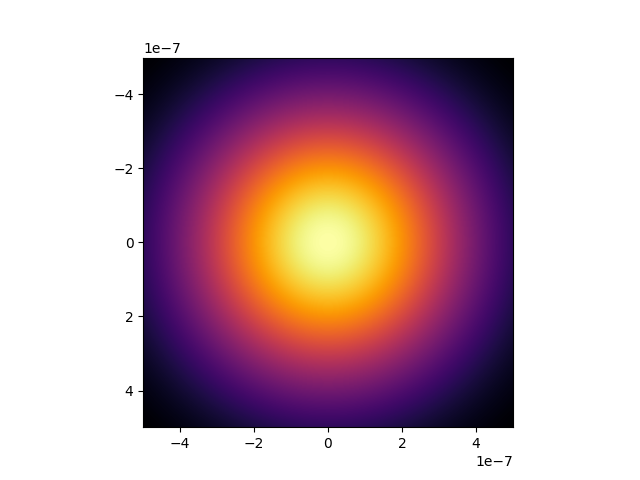

In [5]:
run_model(biprism_deflection=0.0, obj_magnification=-80, projector_magnification=-1, obj_focal_length=1e-2)